In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim
from torchvision import datasets, transforms

import zipfile
import ot

import shutil
import os
import pandas as pd

device = ("cuda" if torch.cuda.is_available() else "cpu") # Use GPU or CPU for training

2024-01-31 11:57:21.109598: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2024-01-31 11:57:23.226994: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-01-31 11:57:23.227111: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2024-01-31 11:57:23.227227: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-01-31 11:57:23.228853: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:13:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.15GiB deviceMemoryBandwidth: 1.76TiB/s
2024-01-31 11:57:23.228912: I tensorflow/stream_executor/cuda/cuda_gpu_

In [2]:
'''with zipfile.ZipFile("celeba.zip","r") as zip_ref:
  zip_ref.extractall("data_faces/")'''

'with zipfile.ZipFile("celeba.zip","r") as zip_ref:\n  zip_ref.extractall("data_faces/")'

In [3]:
'''
root = 'data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))
     '''

"\nroot = 'data_faces/img_align_celeba'\nimg_list = os.listdir(root)\nprint(len(img_list))\n     "

In [4]:
'''
df = pd.read_csv("list_attr_celeba.csv")
df = df[['image_id', 'Smiling']]'''

'\ndf = pd.read_csv("list_attr_celeba.csv")\ndf = df[[\'image_id\', \'Smiling\']]'

In [5]:
# to make directories

'''!rm -rf data
!mkdir data && mkdir data/smile && mkdir data/no_smile'''

'!rm -rf data\n!mkdir data && mkdir data/smile && mkdir data/no_smile'

In [6]:
'''
s0 = 0
s1 = 0

num = 200000

for i, (_, i_row) in enumerate(df.iterrows()):
  if s0 < num:
    if i_row['Smiling'] == 1:
      s0 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])
  
  if s1 < num:
    if i_row['Smiling'] == -1:
      s1 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])
  
  if s0 == num and s1 == num:
    break'''

"\ns0 = 0\ns1 = 0\n\nnum = 200000\n\nfor i, (_, i_row) in enumerate(df.iterrows()):\n  if s0 < num:\n    if i_row['Smiling'] == 1:\n      s0 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])\n  \n  if s1 < num:\n    if i_row['Smiling'] == -1:\n      s1 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])\n  \n  if s0 == num and s1 == num:\n    break"

In [7]:
'''
img_list = os.listdir('data_cel/smile/')
img_list.extend(os.listdir('data_cel/no_smile/'))'''

"\nimg_list = os.listdir('data_cel/smile/')\nimg_list.extend(os.listdir('data_cel/no_smile/'))"

In [8]:
'''print("Images: ", len(img_list))
'''

'print("Images: ", len(img_list))\n'

In [9]:
'''transform = transforms.Compose([
          transforms.Resize((64, 64)),
          transforms.ToTensor()
          ])

batch_size = 64
celeba_data = datasets.ImageFolder('data_cel', transform=transform)'''

"transform = transforms.Compose([\n          transforms.Resize((64, 64)),\n          transforms.ToTensor()\n          ])\n\nbatch_size = 64\nceleba_data = datasets.ImageFolder('data_cel', transform=transform)"

In [10]:
'''print(celeba_data.classes)
print(len(celeba_data))'''

'print(celeba_data.classes)\nprint(len(celeba_data))'

In [11]:
'''
train_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])
train_data_size = len(train_set)
test_data_size = len(test_set)'''

'\ntrain_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])\ntrain_data_size = len(train_set)\ntest_data_size = len(test_set)'

In [12]:
'''trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)
testLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)
'''

'trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)\ntestLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)\n'

In [13]:
'''

print(train_data_size)
print(test_data_size)'''

'\n\nprint(train_data_size)\nprint(test_data_size)'

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from vae import VAE, VAE_big, VAE_big_layered

In [15]:
image_channels = 3

print('image_channels', image_channels)

#model = VAE(image_channels=image_channels).to(device)

model = VAE_big_layered(image_channels=image_channels).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

image_channels 3


In [16]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, size_average=False)
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

def get_kl_divergences(mu_so, std_so, mu_po, std_po):
    dists = torch.tensor([]).to(device)
    for i in range(64):
        mu_po_n = mu_po[i]
        std_po_n = std_po[i]
        distances = 0.5 * torch.sum (((mu_so - mu_po_n)**2 / std_po_n**2) + (std_so**2 / std_po_n**2) - 1 - torch.log(std_so) + torch.log(std_po_n))
        #print(distances.item())
        dists = torch.cat([dists, distances.unsqueeze(0)])
    return dists

def give_mean_sliced_wass_dist(allChImage1, allChImage2):
    mean_wass = 0
    for i in range(3):
        wassDistance = ot.sliced_wasserstein_distance(allChImage1[i], allChImage2[i], seed=0)  
        mean_wass = mean_wass + wassDistance
    return mean_wass/3

In [17]:
model = VAE_big_layered(image_channels=image_channels).to(device)

train_data_size = 105000
epochs = 200
#model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_simple_CNN_VAE_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_CNN_VAE_big_layered_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))


# Set the model to evaluation mode (if needed)
model.eval()

VAE_big_layered(
  (encoder_6): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
  )
  (encoder_5): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (encoder_4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (encoder_3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (encoder_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
  )
  (encoder_1): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
  )
  (encoder_0): Sequential(
    (0): Conv2d(256, 256, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
    (2): Flatten()
  )
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_feature

###### How to calculate KL divergence when you have a multivariate Gaussian

KL_cur = 0.5 * torch.sum (((mu_so - mu_po)**2 / std_po**2) + (std_so**2 / std_po**2) - 1 - torch.log(std_so) + torch.log(std_po))


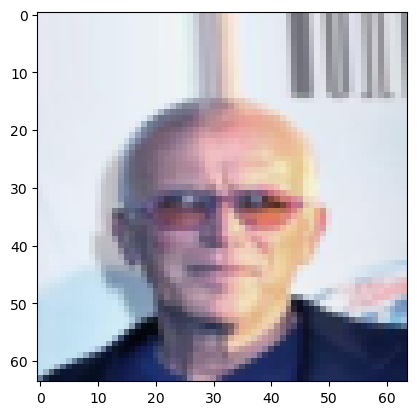

In [18]:
test_ne1 = torch.load("/home/luser/autoencoder_attacks/train_aautoencoders/celeb_neighbours/source_image8.pt")
#test_ne2 = torch.load("/home/luser/autoencoder_attacks/train_aautoencoders/celeb_neighbours/neighbours12.pt")

with torch.no_grad():

    plt.imshow(test_ne1.permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


In [19]:
source_im = test_ne1.unsqueeze(0)
#target_im = test_ne1[-3].unsqueeze(0)
source_im.shape

torch.Size([1, 3, 64, 64])

In [20]:
# Load the autonoiser

from models import AE, CNN_AE_fmnist, Autoencoder_linear_contra_fmnist, MLP_VAE_fmnist, CNN_VAE_fmnist, CNN_AE_fmnist_noiser, CNN_AE_fmnist_noiser_sig, CNN_AE_fmnist_noiser_2sig, CNN_AE_fmnist_noiser_2sig_big
latent_dim = 4
no_channels = 3
activation_cnn_noiser = activation_cnn_noiser = nn.ReLU()

autoenoiser_cnn = CNN_AE_fmnist_noiser_2sig_big(latent_dim, no_channels, activation_cnn_noiser).to(device)
criterion = nn.MSELoss()
import torch.optim as optim
optimizer = optim.Adam(autoenoiser_cnn.parameters(), lr=0.0001)

adv_alpha = 0.35
noiser_epochs = 100000

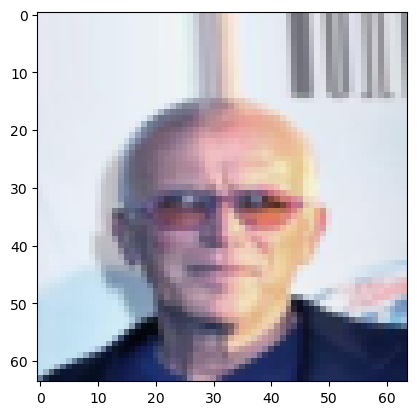

In [21]:
plt.imshow(source_im[0].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


In [22]:
train_loss = []

for epoch in range(noiser_epochs):

    optimizer.zero_grad()
    data = source_im.to(device)
    noise_outputs = autoenoiser_cnn(data)
    noise_outputs = (noise_outputs - 1.0)*0.4
    attacked  = data + noise_outputs
    normalized_attacked = (attacked-attacked.min())/(attacked.max()-attacked.min())
    adv_gen,_,_ = model(normalized_attacked)


    #layerwise drain out of the attack
    layer6e_attacked_out = model.encoder_6(normalized_attacked)
    layer5e_attacked_out = model.encoder_5(layer6e_attacked_out)
    layer4e_attacked_out = model.encoder_4(layer5e_attacked_out)
    layer3e_attacked_out = model.encoder_3(layer4e_attacked_out)
    layer2e_attacked_out = model.encoder_2(layer3e_attacked_out)
    layer1e_attacked_out = model.encoder_1(layer2e_attacked_out)
    layer0e_attacked_out = model.encoder_0(layer1e_attacked_out)
    mu1, logvar1 = model.fc1(layer0e_attacked_out), model.fc2(layer0e_attacked_out)
    std1 = logvar1.mul(0.5).exp_()
    esp1 = torch.randn(*mu1.size()).to(device)
    z1 = mu1 + std1 * esp1
    z1 = model.fc3(z1)
    layer0d_attacked_out = model.decoder_0(z1)
    layer1d_attacked_out = model.decoder_1(layer0d_attacked_out)
    layer2d_attacked_out = model.decoder_2(layer1d_attacked_out)
    layer3d_attacked_out = model.decoder_3(layer2d_attacked_out)
    layer4d_attacked_out = model.decoder_4(layer3d_attacked_out)
    layer5d_attacked_out = model.decoder_5(layer4d_attacked_out)
    #layer6d_attacked_out = model.decoder_6(layer5d_attacked_out) # this layer gives you the actual output of the model

    #layerwise drain out of the normal data
    layer6e_out = model.encoder_6(data)
    layer5e_out = model.encoder_5(layer6e_out)
    layer4e_out = model.encoder_4(layer5e_out)
    layer3e_out = model.encoder_3(layer4e_out)
    layer2e_out = model.encoder_2(layer3e_out)
    layer1e_out = model.encoder_1(layer2e_out)
    layer0e_out = model.encoder_0(layer1e_out)
    mu2, logvar2 = model.fc1(layer0e_out), model.fc2(layer0e_out)
    std2 = logvar2.mul(0.5).exp_()
    esp2 = torch.randn(*mu2.size()).to(device)
    z2 = mu2 + std2 * esp2
    z2 = model.fc3(z2)
    layer0d_out = model.decoder_0(z2)
    layer1d_out = model.decoder_1(layer0d_out)
    layer2d_out = model.decoder_2(layer1d_out)
    layer3d_out = model.decoder_3(layer2d_out)
    layer4d_out = model.decoder_4(layer3d_out)
    layer5d_out = model.decoder_5(layer4d_out)
    #layer6d_out = model.decoder_6(layer5d_out) # this layer gives you the actual output of the model

    #diff norms

    l2DiffsLayerwise = [criterion(data, normalized_attacked), criterion(layer6e_out, layer6e_attacked_out), criterion(layer5e_out, layer5e_attacked_out), criterion(layer4e_out, layer4e_attacked_out), criterion(layer3e_out, layer3e_attacked_out), criterion(layer2e_out, layer2e_attacked_out), criterion(layer1e_out, layer1e_attacked_out), criterion(layer0e_out, layer0e_attacked_out), criterion(mu1, mu2) + criterion(std1, std2) , criterion(layer0d_out, layer0d_attacked_out), criterion(layer1d_out, layer1d_attacked_out), criterion(layer2d_out, layer2d_attacked_out), criterion(layer3d_out, layer3d_attacked_out), criterion(layer4d_out, layer4d_attacked_out), criterion(layer5d_out, layer5d_attacked_out), criterion(data, adv_gen)]
    
    wholeSum = 0
    for i in range(len(l2DiffsLayerwise)-1):
        wholeSum = wholeSum + torch.sum(l2DiffsLayerwise[-1*(i+1)] / torch.stack(l2DiffsLayerwise[:-1*(i+1)]))
    
    total_loss = -1 * torch.log(wholeSum)
    total_loss.backward()
    optimizer.step()
    
    #t_i +=1

    print(f'Epoch [{epoch+1}/{noiser_epochs}], Loss: {total_loss.item():.4f}')
# save the model
#torch.save(autoenoiser_cnn.state_dict(), '/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/allLayerAttackBigLayeredVAECelebA')

torch.save(autoenoiser_cnn.state_dict(), '/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/allLayerOutputAttackBigLayeredVAECelebA1')


Epoch [1/100000], Loss: -8.3286
Epoch [2/100000], Loss: -8.3282
Epoch [3/100000], Loss: -8.3307
Epoch [4/100000], Loss: -8.3285
Epoch [5/100000], Loss: -8.3261
Epoch [6/100000], Loss: -8.3329
Epoch [7/100000], Loss: -8.3257
Epoch [8/100000], Loss: -8.3278
Epoch [9/100000], Loss: -8.3312
Epoch [10/100000], Loss: -8.3291
Epoch [11/100000], Loss: -8.3287
Epoch [12/100000], Loss: -8.3265
Epoch [13/100000], Loss: -8.3331
Epoch [14/100000], Loss: -8.3324
Epoch [15/100000], Loss: -8.3297
Epoch [16/100000], Loss: -8.3338
Epoch [17/100000], Loss: -8.3286
Epoch [18/100000], Loss: -8.3387
Epoch [19/100000], Loss: -8.3340
Epoch [20/100000], Loss: -8.3314
Epoch [21/100000], Loss: -8.3356
Epoch [22/100000], Loss: -8.3346
Epoch [23/100000], Loss: -8.3372
Epoch [24/100000], Loss: -8.3396
Epoch [25/100000], Loss: -8.3458
Epoch [26/100000], Loss: -8.3411
Epoch [27/100000], Loss: -8.3378
Epoch [28/100000], Loss: -8.3379
Epoch [29/100000], Loss: -8.3380
Epoch [30/100000], Loss: -8.3408
Epoch [31/100000], 

In [23]:
# load the autonoiser
#works well
#autoenoiser_cnn.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/LipschitzttNoiser_big_vae_celebA_advAlpha_neighbour13_good1'+str(adv_alpha)+'_'))


#lets see
#autoenoiser_cnn.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/allLayerAttackBigLayeredVAECelebA'))
autoenoiser_cnn.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/allLayerOutputAttackBigLayeredVAECelebA1'))

# Set the model to evaluation mode (if needed)
autoenoiser_cnn.eval()

CNN_AE_fmnist_noiser_2sig_big(
  (input_layer): Sequential(
    (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 16, kernel_size=(8, 8), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(16, 8, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=32, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(8, 2, 2))
    (2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 32, kernel_size=(8, 8), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 16, k

In [24]:
images = source_im

viz_train = images.reshape(-1, 3, 64, 64).to(device)
#viz_adv = images.reshape(-1, 1, 64, 64).to(device)

In [25]:
viz_train.shape

torch.Size([1, 3, 64, 64])

In [31]:
num_steps = 10
path = torch.linspace(0.0, 35.0, num_steps).to(device)

nth_image_ind = 0


#for nth_image_ind in range(viz_train.shape[0]):

n_th_image = viz_train[nth_image_ind].unsqueeze(0)
#n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)

print(n_th_image.shape)
noise_outputs = autoenoiser_cnn(n_th_image)
noise_outputs = (noise_outputs - 1.0)*0.4
#noise_outputs = noise_outputs*0.1

attacked  = n_th_image + noise_outputs
normalized_attacked = (attacked-attacked.min())/(attacked.max()-attacked.min())

so_many_zeros = torch.zeros(num_steps, 3, 64, 64).to(device)
scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

scaled_noises = noise_outputs * scales

scale_noised_images = normalized_attacked + scaled_noises


scale_noised_images = (scale_noised_images - scale_noised_images.min())/(scale_noised_images.max() - scale_noised_images.min())

adv_gen,_,_ = model(scale_noised_images)
#print("adv_gen.shape", adv_gen.shape)
#print("n_th_image.shape", n_th_image.shape)

#diff = torch.sqrt((adv_gen - n_th_image)**2)
each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()
#print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
fooled_out, _, _= model(adv_gen)

each_fooled_out_mse = torch.sqrt((fooled_out - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()

'''bool_mix = (each_adv_gen_mse < 0.1) * (each_fooled_out_mse < 0.1)

    if(True in bool_mix):
        print("bool_mix ", bool_mix )
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())'''

torch.Size([1, 3, 64, 64])


'bool_mix = (each_adv_gen_mse < 0.1) * (each_fooled_out_mse < 0.1)\n\n    if(True in bool_mix):\n        print("bool_mix ", bool_mix )\n        critical_inds_list.append(nth_image_ind)\n        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())'

In [32]:
scale_noised_images[99].max(), scale_noised_images[99].min()

IndexError: index 99 is out of bounds for dimension 0 with size 10

In [33]:
adv_gen[99].max(), adv_gen[99].min(), 

IndexError: index 99 is out of bounds for dimension 0 with size 10

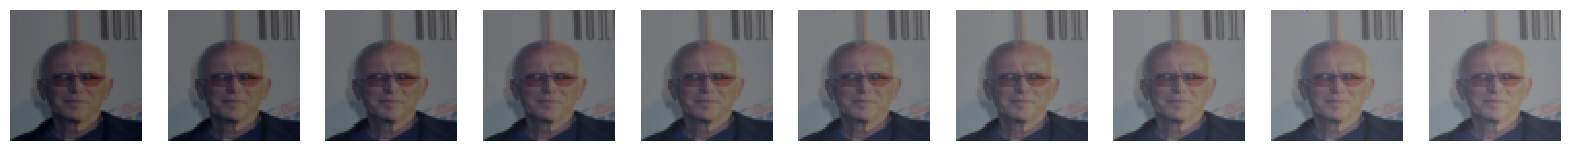

In [34]:
with torch.no_grad():
    fig = plt.figure(figsize=(20,20))
    for i in range(10):
        plt.subplot(1, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        #print(scale_noised_images[i].max(), scale_noised_images[i].min())
        plt.imshow(scale_noised_images[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

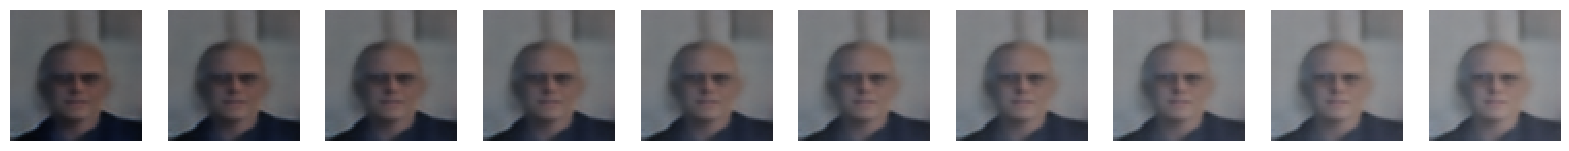

In [35]:
with torch.no_grad():
    fig = plt.figure(figsize=(20,20))
    for i in range(10):
        plt.subplot(1, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(adv_gen[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

In [109]:
scale_noised_images.shape

torch.Size([100, 3, 64, 64])

In [110]:

each_adv_gen_mse = torch.sqrt((scale_noised_images - adv_gen)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
each_adv_gen_mse.shape


torch.Size([100])

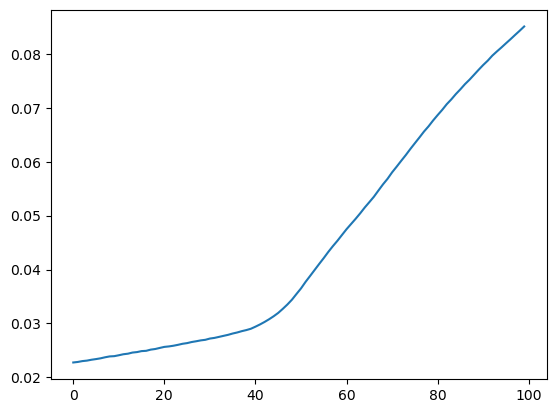

In [111]:
plt.plot(each_adv_gen_mse.cpu().detach().numpy())


In [112]:
each_adv_gen_mse.max()

tensor(0.0851, device='cuda:0', grad_fn=<MaxBackward1>)

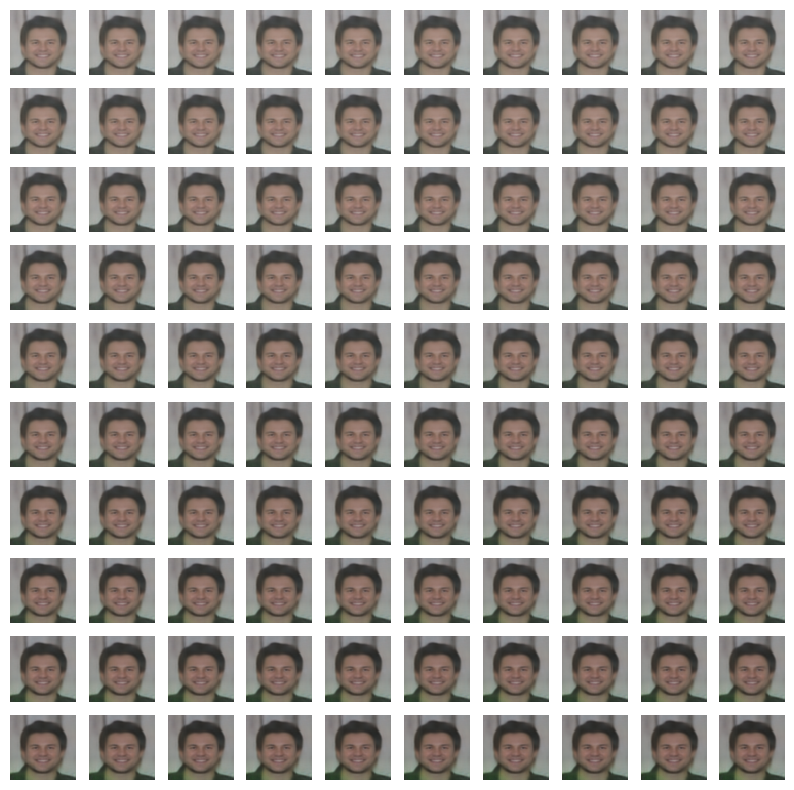

In [38]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(fooled_out[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

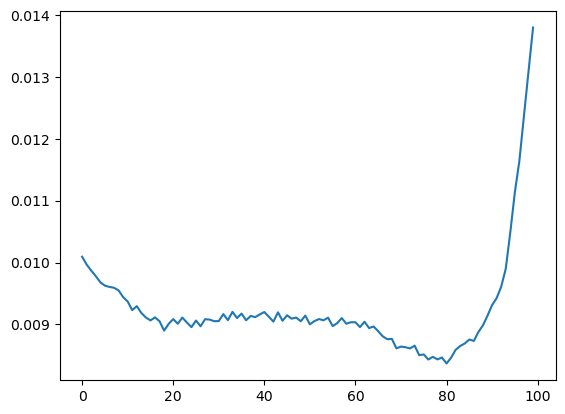

In [31]:
find_bad_guy = torch.sqrt((adv_gen - fooled_out)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
plt.plot(find_bad_guy.cpu().detach().numpy())

In [32]:
find_bad_guy > 0.011

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True,  True,  True,  True],
       device='cuda:0')

In [33]:
selected_gens = adv_gen[find_bad_guy > 0.011]

In [34]:
selected_gens.shape, adv_gen.shape

(torch.Size([5, 3, 64, 64]), torch.Size([100, 3, 64, 64]))

In [35]:
selected_fooled_outs, _, _= model(selected_gens)


IndexError: index 5 is out of bounds for dimension 0 with size 5

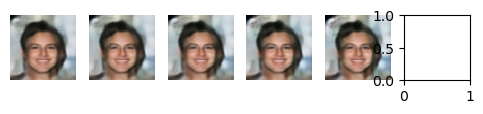

In [36]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(selected_gens[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

IndexError: index 5 is out of bounds for dimension 0 with size 5

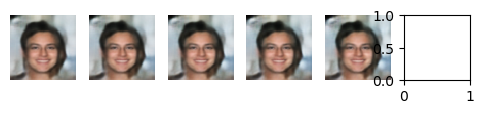

In [37]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(selected_fooled_outs[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

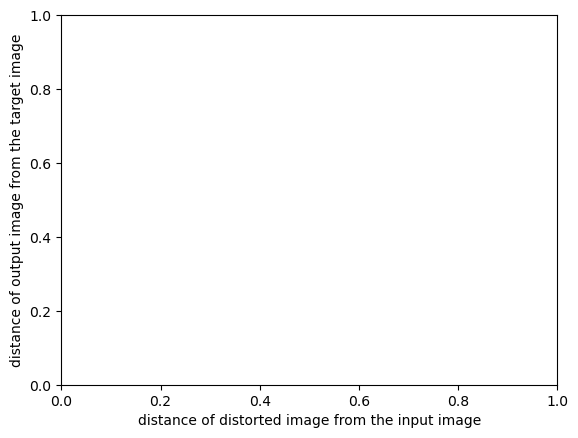

In [54]:
num_steps = 200
path = torch.linspace(0.0, 1.0, num_steps).to(device)

nth_image_ind = 0

critical_inds_list = []

all_selected_adv_gens = torch.tensor([]).to(device)
all_selected_scale_noised_images = torch.tensor([]).to(device)
all_selected_n_th_image = torch.tensor([]).to(device)

for nth_image_ind in range(viz_train.shape[0]):

    n_th_image = viz_train[nth_image_ind].unsqueeze(0)
    #n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)


    noise_outputs = autoenoiser_cnn(n_th_image)
    noise_outputs = (noise_outputs - 1.0)*2.0

    so_many_zeros = torch.zeros(num_steps, 3, 64, 64).to(device)
    scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

    scaled_noises = noise_outputs * scales

    scale_noised_images = n_th_image + scaled_noises
    n_th_image_trick = n_th_image + scaled_noises*0.0
    adv_gen,_,_ = model(scale_noised_images)

    
    #diff = torch.sqrt((adv_gen - n_th_image)**2)
    each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
    #each_adv_gen_mse = torch.sqrt((adv_gen - adv_gen[0].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
    fooled_out, _, _= model(adv_gen)

    #each_fooled_out_mse = torch.sqrt((fooled_out - adv_gen)**2).mean(dim=(2, 3), keepdim=True).squeeze()
    each_fooled_out_mse = torch.sqrt((fooled_out - n_th_image)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
    #each_fooled_out_mse = torch.sqrt((fooled_out - fooled_out[-1].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #print("each_fooled_out_mse.max(), each_fooled_out_mse.min()", each_fooled_out_mse.max(), each_fooled_out_mse.min())
    #print("each_adv_gen_mse.max(), each_adv_gen_mse.max()", each_adv_gen_mse.max(), each_adv_gen_mse.min())
    #bool_mix = (each_adv_gen_mse < 0.06) * (each_fooled_out_mse > 0.021)

    only_fooled_out_loss = torch.sqrt((fooled_out - adv_gen)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()

    bool_mix = (only_fooled_out_loss > 0.02) * (each_adv_gen_mse < 0.15)

    #bool_mix = (each_adv_gen_mse < 0.16) * (each_fooled_out_mse > 0.25)

    #bool_mix = (each_fooled_out_mse > 0.1)
    
    #bool_mix = (each_adv_gen_mse < 0.06) * (each_fooled_out_mse > 0.02)



    if(True in bool_mix):
        #print("bool_mix ", bool_mix )

        selected_adv_gens = adv_gen[bool_mix]
        selected_scale_noised_images = scale_noised_images[bool_mix]
        selected_n_th_image = n_th_image_trick[bool_mix]

        all_selected_adv_gens = torch.cat((all_selected_adv_gens, selected_adv_gens))
        all_selected_scale_noised_images = torch.cat((all_selected_scale_noised_images, selected_scale_noised_images))
        all_selected_n_th_image = torch.cat((all_selected_n_th_image, selected_n_th_image))
        #print("all_selected_adv_gens.shape", all_selected_adv_gens.shape)
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), only_fooled_out_loss.cpu().detach().numpy())
    plt.xlabel("distance of distorted image from the input image")
    plt.ylabel("distance of output image from the target image")

In [ ]:
len(critical_inds_list)

In [ ]:
all_selected_adv_gens.shape

In [ ]:
fooled_out_act, _, _= model(all_selected_adv_gens)


In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_adv_gens[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(fooled_out_act[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_scale_noised_images[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_n_th_image[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()